In [62]:
import h5py, glob
import matplotlib.pyplot as plt
import agama
agama.setUnits(mass=1, length=1, velocity=1)
import numpy as np
pot_mw = agama.Potential('/suphys/aani0116/minicluster/minicluster_tidal/Agama/data/McMillan17.ini')

files = glob.glob('/suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/*.h5')
for i,j in enumerate(files):
    print(i, files[i])


0 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-07_c10.h5
1 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-06_c10.h5
2 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-08_13B_c10.h5
3 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-10_13B_c10.h5
4 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-06_13B_c10.h5
5 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-07_13B_c10.h5
6 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-11_13Bcoarse_c10.h5
7 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-09_0.01_c10.h5
8 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-11_t1_dt0.0001_c10.h5
9 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-11_t1_dt0.0001_c10_2.h5
10 /suphys/aani0116/Work/minicluster_tidal/hpc/Sigma_test/data/mc_m1.0e-09_t1_dt0.0001_c10.h5
11 /suphys/aani0116/Work/minicluster_ti

In [76]:
with h5py.File(files[2], 'r') as f:
    mcp_xv     = f['mcp_xv'][:]
    bound      = f['bound'][:]
    E_p        = f['E_p'][:]
    mc_xv      = f['mc_xv'][:]
    snap_times = f['snap_times'][:]
    
    mcp_mass        = f.attrs['mcp_mass']
    Nbody           = f.attrs['Nbody']
    simulation_time = f.attrs['simulation_time']
    tupd            = f.attrs['tupd']
    mc_mass         = f.attrs['mc_mass']
    mc_delta        = f.attrs['mc_delta']
    mc_radius       = f.attrs['mc_radius']
    mc_radius_char  = f.attrs['mc_radius_char']
    mc_density_char = f.attrs['mc_density_char']
    mc_concentration= f.attrs['mc_concentration']
    ic=f.attrs['ic']
print(ic,mc_xv[-1])


[   2.0161183    4.1744533    6.2138557  -61.644123  -107.7965
  151.23167  ] [ 7.9991078e+00 -5.3915434e-04 -3.9218243e-02  6.2164164e+00
  5.0000019e+00  2.1997768e+02]


In [77]:
s_orbit = agama.orbit(ic=ic, potential=pot_mw, time=simulation_time, dtype=object)
t = np.linspace(0, simulation_time, 10000)



<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2625749/2542217123.py:28: SyntaxWarning: invalid escape sequence '\o'
  fig.suptitle(f'MC Mass = {mc_mass:.2e} M$_\odot$', fontsize=20)


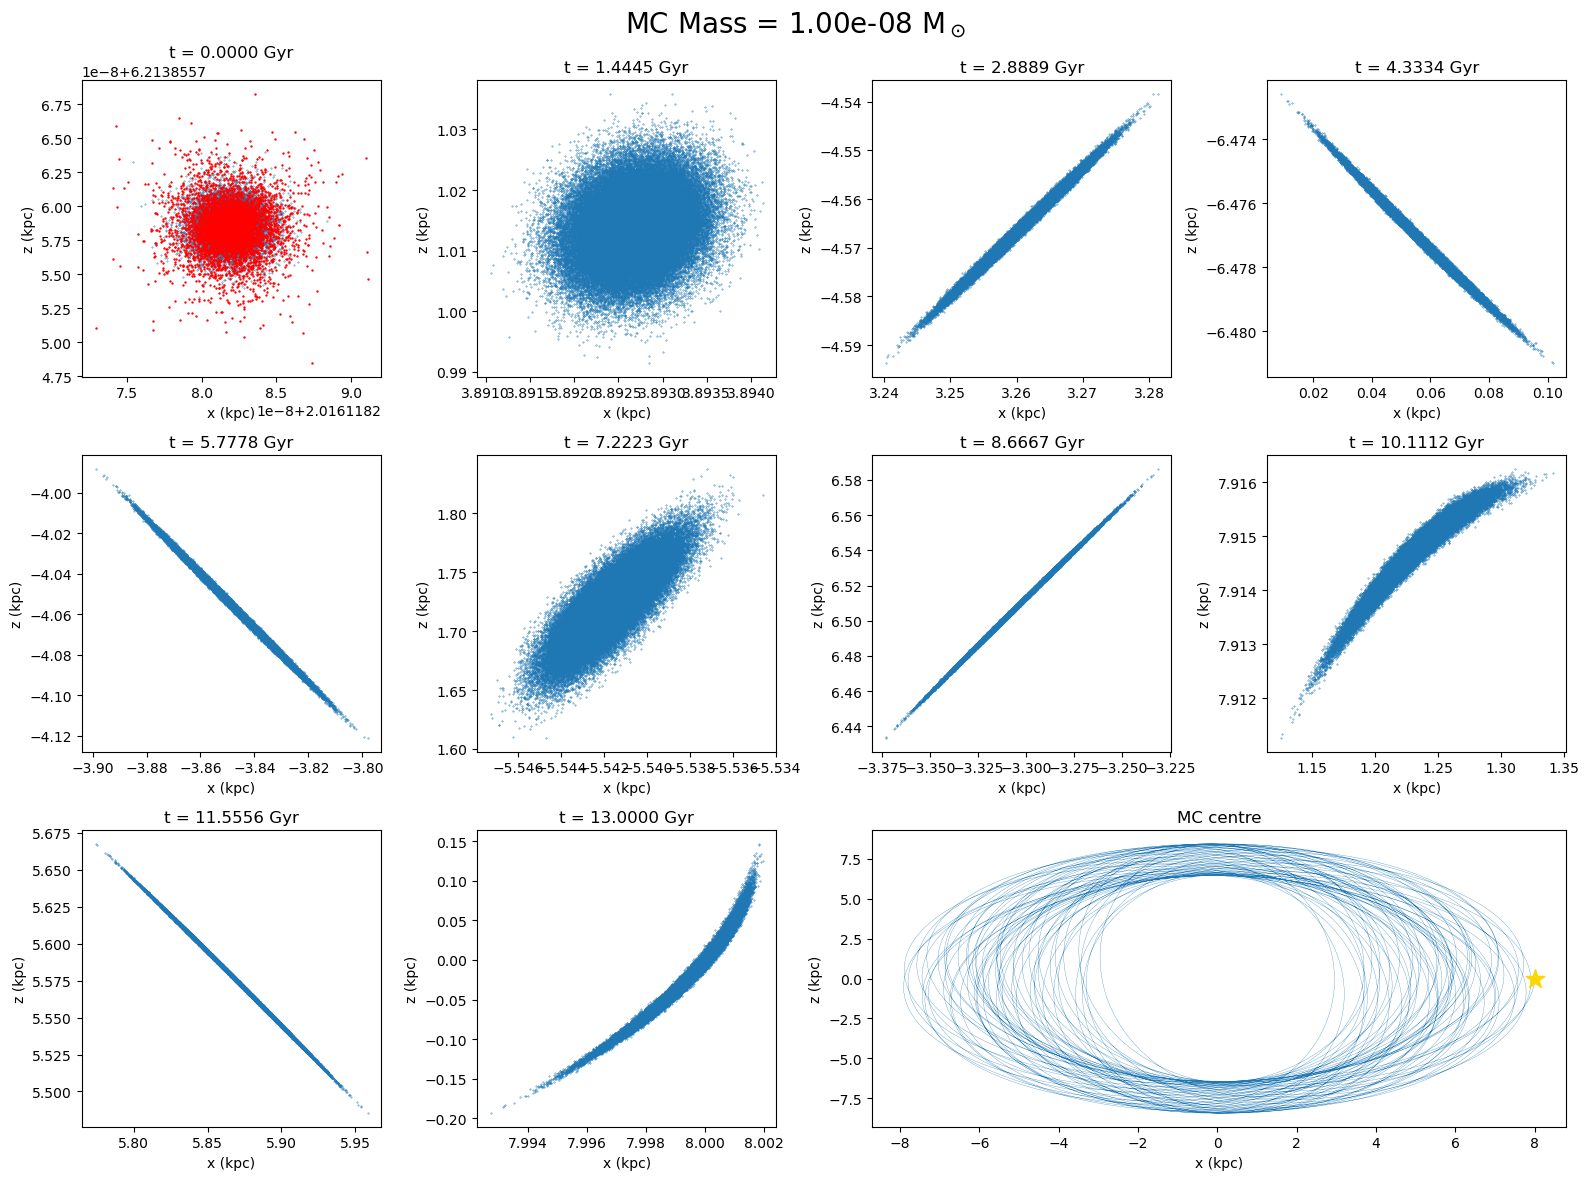

In [78]:


a = 0
b = 2
labels = {0: 'x (kpc)', 1: 'y (kpc)', 2: 'z (kpc)', 3: 'vx (km/s)', 4: 'vy (km/s)', 5: 'vz (km/s)'}

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, ax in enumerate(axes.flat):
    if i < 10:
        ax.scatter(mcp_xv[i][:,a][~bound[i]]+mc_xv[i,a], mcp_xv[i][:,b][~bound[i]]+mc_xv[i,b], s=0.1)
        ax.scatter(mcp_xv[i][:,a][bound[i]]+mc_xv[i,a], mcp_xv[i][:,b][bound[i]]+mc_xv[i,b], s=0.5, color='red')
        ax.set_title(f't = {snap_times[i]:.4f} Gyr')
        ax.set_xlabel(labels[a])
        ax.set_ylabel(labels[b])
    elif i == 10:
        ax.plot(s_orbit(t)[:,a], s_orbit(t)[:,b], lw=0.2)
        
        #ax.scatter(mc_xv[:,a], mc_xv[:,b], marker='o', color='blue', s=10, zorder=5)
        #for j in range(len(mc_xv)):
         #   ax.annotate(str(j+1), (mc_xv[j,a], mc_xv[j,b]), textcoords='offset points', xytext=(5,5), fontsize=17, color='blue')

        ax.set_title('MC centre')
        ax.set_xlabel(labels[a])
        ax.set_ylabel(labels[b])
        sun = [8.0, 0.0, 0.0]
        ax.scatter(sun[a], sun[b], marker='*', color='gold', s=200, zorder=5)

    else:
        ax.set_visible(False)
fig.suptitle(f'MC Mass = {mc_mass:.2e} M$_\odot$', fontsize=20)
plt.tight_layout()

pos10 = axes[2, 2].get_position()
pos11 = axes[2, 3].get_position()
axes[2, 2].set_position([pos10.x0, pos10.y0, pos11.x1 - pos10.x0, pos10.height])


In [79]:
pos_f=mcp_xv[-1][:,:3]
vel_f=mcp_xv[-1][:,3:6]

(array([1.2056e+04, 1.2048e+04, 1.1476e+04, 1.0590e+04, 9.8830e+03,
        8.4420e+03, 7.2840e+03, 6.0280e+03, 5.0470e+03, 4.0700e+03,
        3.2190e+03, 2.6100e+03, 1.9950e+03, 1.4350e+03, 1.1130e+03,
        8.0900e+02, 6.1400e+02, 4.1800e+02, 3.0100e+02, 1.8900e+02,
        1.4600e+02, 9.4000e+01, 4.9000e+01, 4.0000e+01, 2.0000e+01,
        9.0000e+00, 6.0000e+00, 6.0000e+00, 1.0000e+00, 2.0000e+00]),
 array([2.14923110e-04, 1.96355447e-01, 3.92495970e-01, 5.88636494e-01,
        7.84777018e-01, 9.80917541e-01, 1.17705806e+00, 1.37319859e+00,
        1.56933911e+00, 1.76547964e+00, 1.96162016e+00, 2.15776068e+00,
        2.35390121e+00, 2.55004173e+00, 2.74618225e+00, 2.94232278e+00,
        3.13846330e+00, 3.33460382e+00, 3.53074435e+00, 3.72688487e+00,
        3.92302540e+00, 4.11916592e+00, 4.31530644e+00, 4.51144697e+00,
        4.70758749e+00, 4.90372801e+00, 5.09986854e+00, 5.29600906e+00,
        5.49214958e+00, 5.68829011e+00, 5.88443063e+00]),
 <BarContainer object of 30 

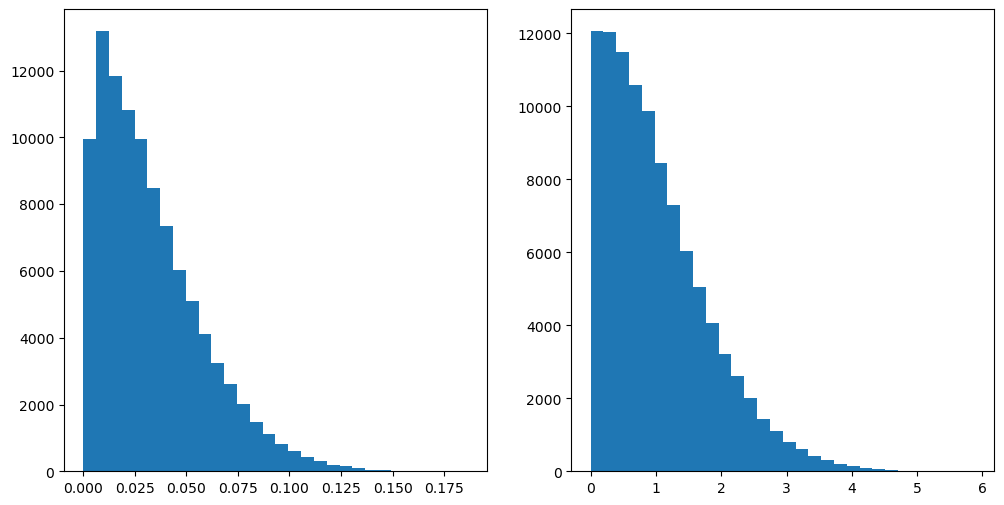

In [80]:
fig,ax=plt.subplots(1,2,figsize=(12,6))
ax[0].hist(np.linalg.norm(pos_f, axis=1), bins=30)
ax[1].hist(np.linalg.norm(vel_f, axis=1), bins=30)


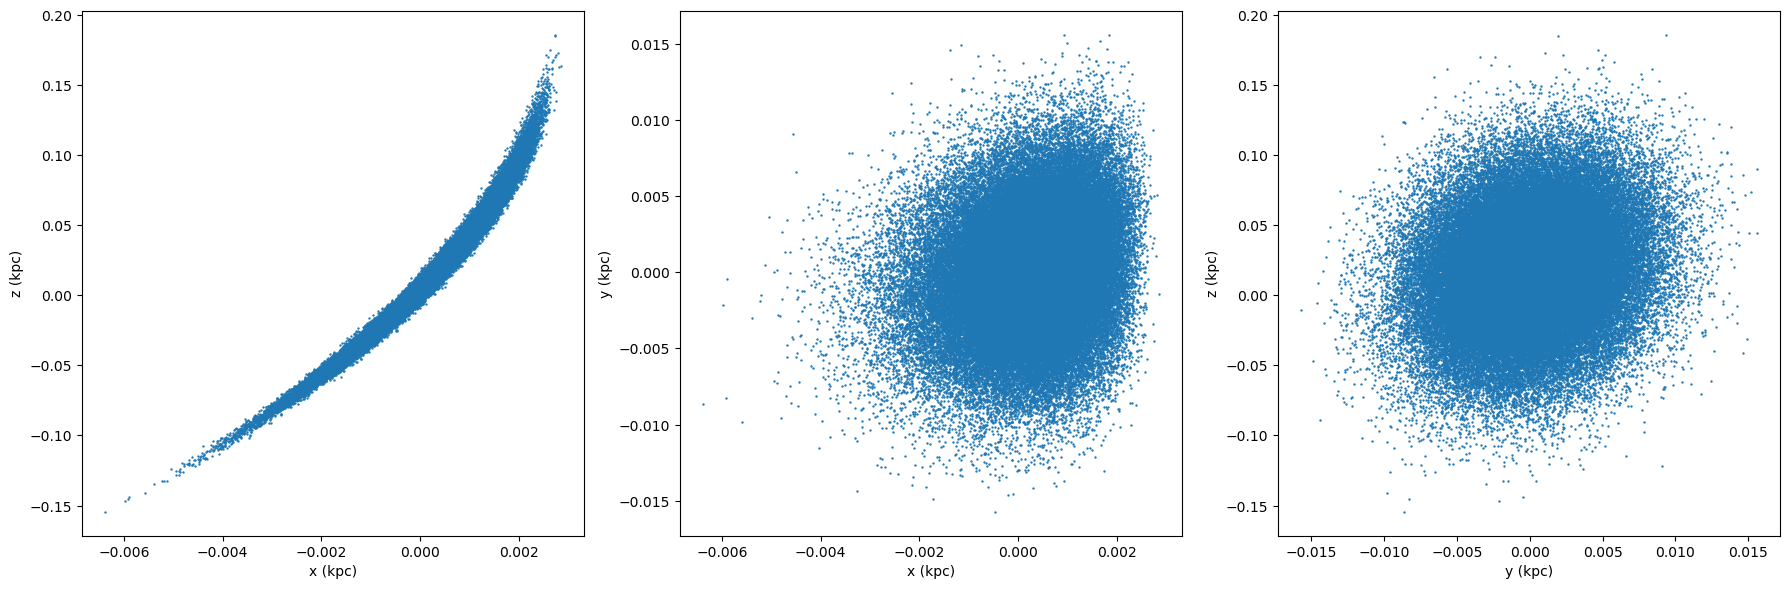

In [95]:
fig,ax=plt.subplots(1,3,figsize=(18,6))
ax[0].scatter(pos_f[:,0], pos_f[:,2], s=0.5)

ax[1].scatter(pos_f[:,0], pos_f[:,1], s=0.5)
ax[2].scatter(pos_f[:,1], pos_f[:,2], s=0.5)
ax[0].set_xlabel('x (kpc)')
ax[0].set_ylabel('z (kpc)')
ax[1].set_xlabel('x (kpc)')
ax[1].set_ylabel('y (kpc)')
ax[2].set_xlabel('y (kpc)')
ax[2].set_ylabel('z (kpc)')
fig.tight_layout()

In [84]:
np.cov(pos_f.T)

array([[1.00256903e-06, 6.84644082e-07, 3.68991895e-05],
       [6.84644082e-07, 1.34803289e-05, 2.52671166e-05],
       [3.68991895e-05, 2.52671166e-05, 1.40785216e-03]])

In [85]:
eigenvalues, eigenvectors = np.linalg.eigh(cov)



In [86]:
eigenvectors

array([[-0.98073225,  0.01089683, -0.19505257],
       [-0.0066392 , -0.9997255 , -0.0224686 ],
       [ 0.19524386,  0.02074069, -0.98053539]])

Variance along each axis: [1.40927703e-03 1.30226393e-05 3.53945174e-08]


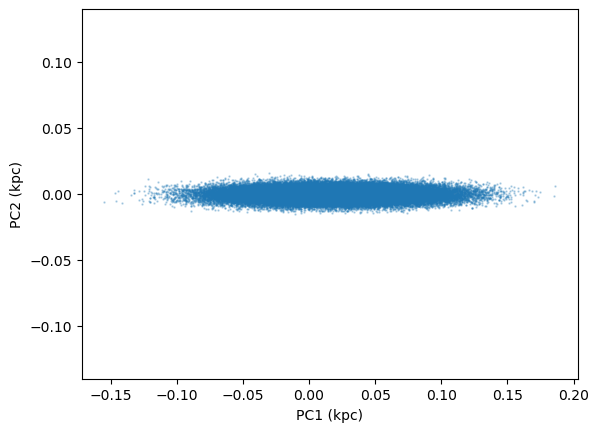

In [96]:
cov = np.cov(pos_f.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

pos_rot = pos_f @ eigenvectors

print("Variance along each axis:", eigenvalues)

plt.scatter(pos_rot[:, 0], pos_rot[:, 1], s=0.5, alpha=0.3)
plt.xlabel('PC1 (kpc)')
plt.ylabel('PC2 (kpc)')
plt.axis('equal')
plt.show()


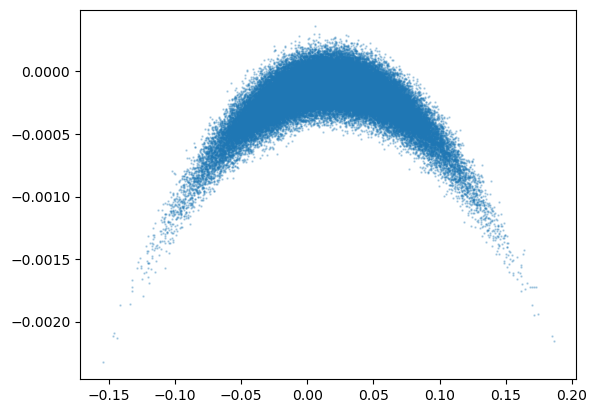

In [99]:
plt.scatter(pos_rot[:, 0], pos_rot[:, 2], s=0.5, alpha=0.3)
